In [34]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import umap
from pathlib import Path

API_URL = "http://localhost:8080/embedding"

IMAGE_LABELS = {
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0010_0010_034.JPG": 0,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0010_0010_035.JPG":0,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0010_0010_033.JPG": 0,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0010_0010_031.JPG": 1,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0010_0010_030.JPG": 1,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0010_0010_023.JPG": 1,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0009_0009_003.JPG": 2,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0009_0009_006.JPG": 2,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0009_0009_009.JPG": 2,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0007_0007_028.JPG": 3,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0007_0007_022.JPG": 3,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0007_0007_007.JPG" : 3,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0005_0005_008.JPG": 4,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0005_0005_007.JPG" :4,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0005_0005_000.JPG": 4,
    "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0005_0005_014.JPG" : 4


}

In [49]:
embeddings = []
labels = []
filenames = []

In [ ]:
root = "/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/"
IMAGE_LABELS = dict()

#cat1
for i in range(10, 25):
    IMAGE_LABELS[f"{root}0010_0010_0{i}.JPG"] = 1

#cat2
for i in range(0, 10):
    IMAGE_LABELS[f"{root}0006_0006_00{i}.JPG"] = 2

#cat3
for i in range(0, 7):
    IMAGE_LABELS[f"{root}0001_0001_00{i}.JPG"] = 3

In [65]:
embeddings = embeddings.tolist()

In [66]:
IMAGE_LABELS = dict()

#cat3
for i in range(0, 7):
    IMAGE_LABELS[f"{root}0001_0001_00{i}.JPG"] = 3

In [60]:
for filename, label in IMAGE_LABELS.items():
    with open(filename, "rb") as f:
        files = {"file": (filename, f, "image/jpeg")}
        response = requests.post(API_URL, files=files)
        response.raise_for_status()
        data = response.json()
        embeddings.append(data["embedding"])
        labels.append(label)
        filenames.append(filename)
        print(f"Processed {filename} -> embedding length {len(data['embedding'])}")

Processed /home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0001_0001_000.JPG -> embedding length 2560
Processed /home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0001_0001_001.JPG -> embedding length 2560
Processed /home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0001_0001_002.JPG -> embedding length 2560
Processed /home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0001_0001_003.JPG -> embedding length 2560
Processed /home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0001_0001_004.JPG -> embedding length 2560
Processed /home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0001_0001_005.JPG -> embedding length 2560
Processed /home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/data/test/images/0001_0001_006.JPG -> embedding length 2560


In [61]:
embeddings = np.array(embeddings)   # shape (6, 2560)
labels = np.array(labels)

In [62]:
reducer = umap.UMAP(n_components=2, random_state=42, metric="cosine")
embeddings_2d = reducer.fit_transform(embeddings)

/home/nikita/Documents/StudCampMs2026Alice/PPGNet-Cat/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


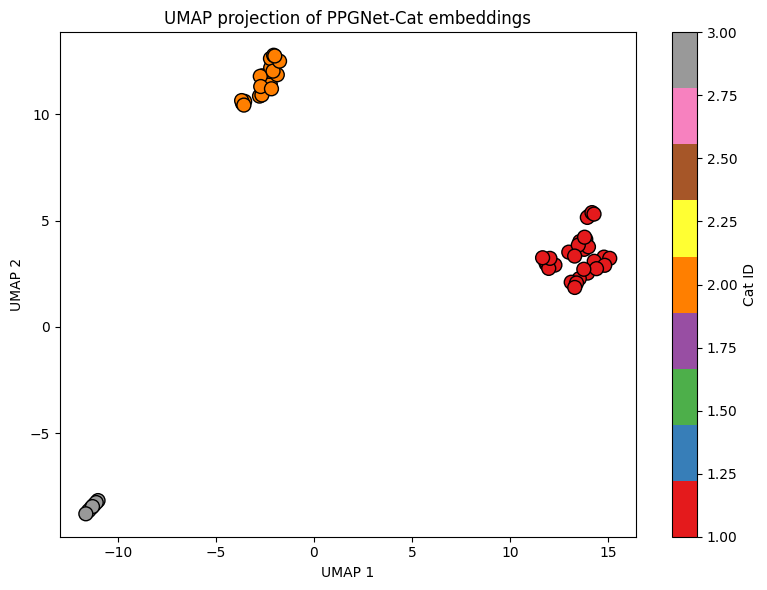

In [64]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    cmap="Set1",
    s=100,
    edgecolor="k"
)

# Annotate points with filenames
for i, name in enumerate(filenames):
    plt.annotate('', (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 xytext=(5, 5), textcoords="offset points", fontsize=8)

plt.title("UMAP projection of PPGNet‑Cat embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cat ID")
plt.tight_layout()
plt.savefig("umap_embeddings.png", dpi=150)
plt.show()